In [1]:
import cv2
import matplotlib.pyplot as plt

Reading and displaying an image

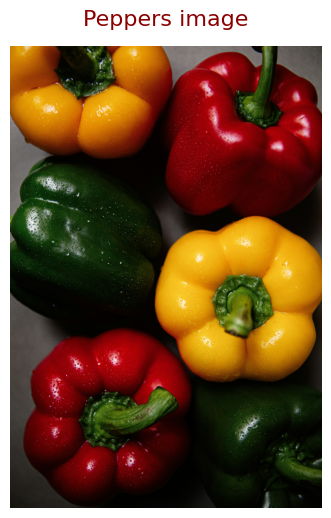

In [2]:
image_path = "peppers.jpg"
image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.axis('off')

plt.title("Peppers image", fontsize = 16, color = 'darkred', pad = 15)

plt.imshow(image_rgb)
plt.show()

Grayscale image

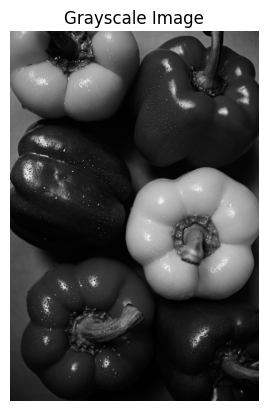

In [3]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

Resize Image

In [4]:
resize_factor = 0.5
resized_image = cv2.resize(image_rgb, None, fx = resize_factor, fy=resize_factor)
new_height, new_width = resized_image.shape[:2]
old_height, old_width = image_rgb.shape[:2]

print(f"New resolution: {new_width}x{new_height}")
print(f"Old resolution: {old_width}x{old_height}")

New resolution: 1798x2670
Old resolution: 3595x5339


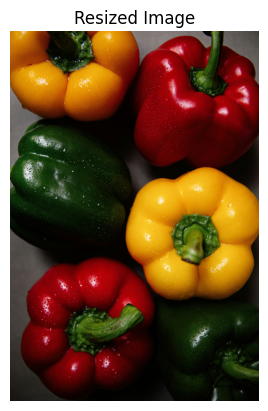

In [5]:
plt.imshow(resized_image)
plt.title("Resized Image")
plt.axis('off')
plt.show()

Image blur


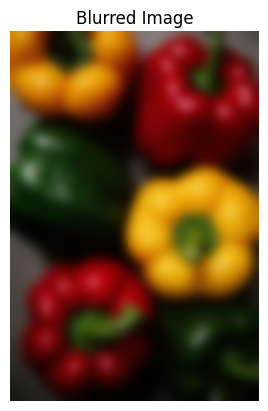

In [6]:
blurred_image = cv2.GaussianBlur(image_rgb, (501,501), 0)
plt.imshow(blurred_image)
plt.title("Blurred Image")
plt.axis('off')
plt.show()

Image Cropping


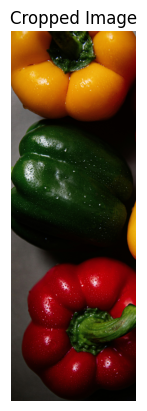

In [7]:
mid_x = old_width // 2
# keeps the left half
cropped_image = image_rgb[:, :mid_x]
# to keep the right half instead, we can do:
# cropped_image = image_rgb[:,mid_x:]

plt.imshow(cropped_image)
plt.title("Cropped Image")
plt.axis('off')
plt.show()

Adding text on image

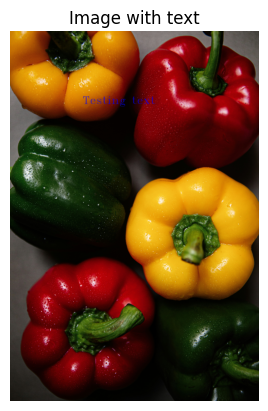

In [8]:
text = "Testing text"
font = cv2.FONT_HERSHEY_TRIPLEX
cv2.putText(image_rgb, text, (1050,1050), font, 5, (0,0,255), 2)

plt.imshow(image_rgb)
plt.title("Image with text")
plt.axis('off')
plt.show()

Analyzing image using pandas

In [9]:
import pandas as pd
from IPython.display import display

# flattening the image and then converting it to a pandas dataframe
flattened_image = image.reshape(-1, 3)

image_df = pd.DataFrame(flattened_image, columns = ['B', 'G', 'R'])

image_df.head()
display(image_df.describe())

,B,G,R
count,1.919370e+07,1.919370e+07,1.919370e+07
mean,1.566566e+01,4.945654e+01,8.856004e+01
std,3.021926e+01,5.808372e+01,7.864040e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,4.000000e+00,1.400000e+01
50%,4.000000e+00,2.200000e+01,7.000000e+01
75%,1.300000e+01,8.400000e+01,1.450000e+02
max,2.550000e+02,2.550000e+02,2.550000e+02


Image Thresholding

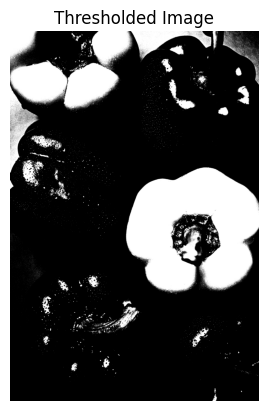

In [10]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#Apply binary thresholding
ret, thresholded_image = cv2.threshold(gray_image, 100, 255, cv2.THRESH_BINARY)

plt.imshow(thresholded_image, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()


Image Rotation

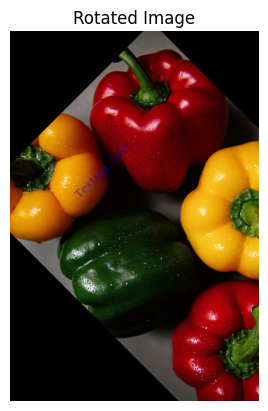

In [11]:
height, width = image_rgb.shape[:2]

center = (height/2, width/2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1)

rotated_image = cv2.warpAffine(image_rgb, rotation_matrix, (width, height))

plt.imshow(rotated_image)
plt.title("Rotated Image")
plt.axis('off')
plt.show()

Image blending

In [12]:
image1 = cv2.imread("peppers.jpg")
image2 = cv2.imread("fruits.jpg")

In [13]:
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

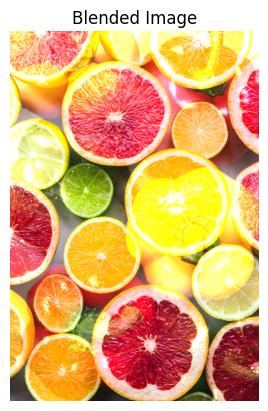

In [14]:
target_height, target_width = image1_rgb.shape[:2]
image2_resized = cv2.resize(image2_rgb, (target_width, target_height))

blended_image = cv2.add(image1_rgb, image2_resized)

plt.imshow(blended_image)
plt.title("Blended Image")
plt.axis('off')
plt.show()

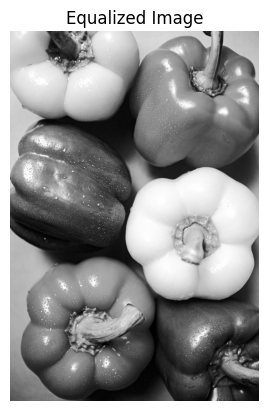

In [15]:
image = cv2.imread("peppers.jpg", cv2.IMREAD_GRAYSCALE)

equalized_image = cv2.equalizeHist(image)

plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')
plt.show()

# **LAB 01 - TASKS**

In [16]:
# Object oriented grocery manager

In [17]:
class GroceryManager:
  def __init__(self):
    self.items = {}

  def add_item(self, item, quality, price):
    self.items[item] = {
        "quality": quality,
        "price": price
    }

  def remove_item(self, item):
    if item in self.items:
      del self.items[item]
      print(f"{item} removed from the grocery list.")
    else:
      print(f"{item} not found in the grocery list.")

  def view_list(self):
      if len(self.items) == 0:
        print("Grocery list is empty")

      else:
        for item in self.items:
          print(item, self.items[item])

  def calculate_total(self):
      for item in self.items:
        total = self.items[item]["quality"] * self.items[item]["price"]
      print(f"Total price: {total}")

# Create an object
grocery = GroceryManager()

# Add items
grocery.add_item("Milk", 2, 200)
grocery.add_item("Bread", 3, 100)
grocery.add_item("Eggs", 12, 30)

# View grocery list
print("\nGrocery List:")
grocery.view_list()

# Calculate total cost
grocery.calculate_total()

# Remove an item
grocery.remove_item("Bread")

# View updated list
print("\nUpdated Grocery List:")
grocery.view_list()


Grocery List:
Milk {'quality': 2, 'price': 200}
Bread {'quality': 3, 'price': 100}
Eggs {'quality': 12, 'price': 30}
Total price: 360
Bread removed from the grocery list.

Updated Grocery List:
Milk {'quality': 2, 'price': 200}
Eggs {'quality': 12, 'price': 30}


In [18]:
# Advanced Student Record System
students = {
    101: {
        "Name": "Adina",
        "Major": "Computer Science",
        "Grades": [80,90,85]
    },
    102: {
        "Name": "Sara",
        "Major": "Software Engineering",
        "Grades": [95, 90, 100]
    },
    103: {
        "Name": "Ahmed",
        "Major": "Computer Science",
        "Grades": [70, 75, 80]
    }
}

In [19]:
def highest_average(students):
  highest = 0
  student_name= ""

  for student_id in students:
    grades = students[student_id]["Grades"]
    avg = sum(grades)/len(grades)
    if avg > highest:
      highest = avg
      student_name = students[student_id]["Name"]
  print("Student with highest average:", student_name)
  print("Average grade:", highest)

def search_major(students, major):
  for s in students:
    if students[s]["Major"] == major:
      print("ID: ", s)
      print("Student name: ", students[s]["Name"])
      found = True
  if found == False:
    print("No students with such major found")
# Find the student with the highest average
highest_average(students)

# Search by major
print("\nStudents in Computer Science:")
search_major(students, "Computer Science")

Student with highest average: Sara
Average grade: 95.0

Students in Computer Science:
ID:  101
Student name:  Adina
ID:  103
Student name:  Ahmed


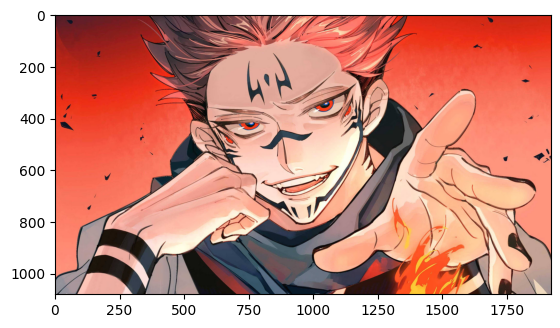

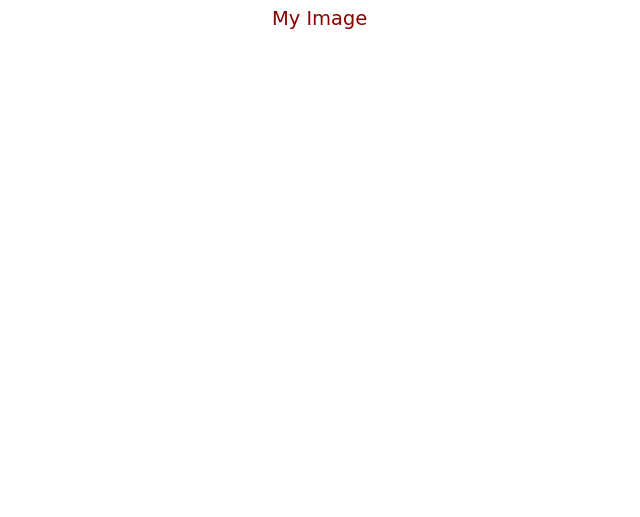

In [ ]:
# safe image loading and rgb visualization

sukuna = cv2.imread("sukuna.jpg")
sukuna_rgb = cv2.cvtColor(sukuna, cv2.COLOR_BGR2RGB)

plt.imshow(sukuna_rgb)
plt.figure(figsize=(8,6))
plt.axis("off")
plt.title(
        "My Image",
        fontsize=14,
        color="darkred",
        pad=15
    )
plt.show()

In [ ]:
#TASK 04
#  interactive geometry and blank canvas
# pehle 5 alternating concentric circles banao then ek rectangle banao uske ird gird

import numpy as np
canvas = np.zeros((300,300,3), dtype = np.uint8)
center = (150, 150)

cv2.circle(canvas, center, 120, (0,0,255), -1)
cv2.circle(canvas, center, 95, (255,255,255), -1)
cv2.circle(canvas, center, 70, (0,0,255), -1)
cv2.circle(canvas, center, 45, (255,255,255), -1)
cv2.circle(canvas, center, 20, (0,0,255), -1)

cv2.rectangle(canvas, (30,30), (270,270), (0,255,0), 2)

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

plt.imshow(canvas_rgb)
plt.title("Concentric circles")
plt.axis("off")
plt.show()

NameError: name 'cv2' is not defined

In [ ]:
image_rgb

array([[[201, 122,   1],
        [206, 127,   6],
        [208, 129,   8],
        ...,
        [ 75,  71,  62],
        [ 69,  65,  56],
        [ 82,  78,  69]],

       [[205, 126,   5],
        [203, 124,   3],
        [202, 123,   2],
        ...,
        [ 87,  83,  74],
        [ 51,  47,  38],
        [ 85,  81,  72]],

       [[198, 119,   0],
        [203, 124,   3],
        [204, 125,   4],
        ...,
        [ 58,  54,  45],
        [ 64,  60,  51],
        [ 67,  63,  54]],

       ...,

       [[ 19,  18,  14],
        [ 16,  15,  11],
        [ 16,  15,  11],
        ...,
        [  4,   4,   2],
        [  3,   3,   1],
        [  2,   2,   0]],

       [[ 19,  18,  14],
        [ 21,  20,  16],
        [ 18,  17,  13],
        ...,
        [  4,   4,   2],
        [  3,   3,   1],
        [  2,   2,   0]],

       [[ 18,  19,  14],
        [ 27,  28,  23],
        [ 20,  21,  16],
        ...,
        [  4,   4,   2],
        [  3,   3,   1],
        [  2,   2,   0]]

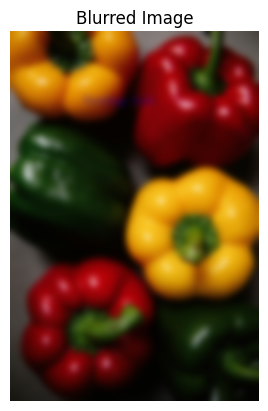

In [23]:
blurred_image = cv2.GaussianBlur(image_rgb, (305,305), 0)
plt.imshow(blurred_image)
plt.title("Blurred Image")
plt.axis('off')
plt.show()

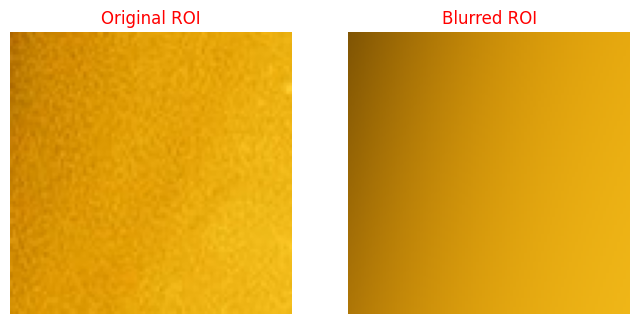

In [ ]:
# TASK 05
# Advanced blurring and ROI calculation

height, width = image_rgb.shape[:2]
center_x = width // 2
center_y = height // 2

original_roi = image_rgb[center_y-50: center_y+50, center_x-50:center_x+50]
blurred_roi = blurred_image[center_y-50: center_y+50, center_x-50:center_x+50]

plt.figure(figsize= (8, 4))

plt.subplot(1,2,1)
plt.imshow(original_roi)
plt.title("Original ROI", fontsize = 12, color = "red")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blurred_roi)
plt.title("Blurred ROI", fontsize = 12, color = "red")
plt.axis("off")

plt.show()

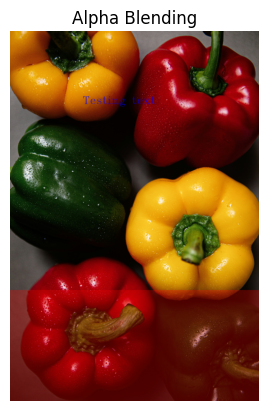

In [ ]:
# TASK 06
# Alpha blending and typogrphy
# blend the original image with a blue rectangle at the bottom and add text on top of it

overlay = image_rgb.copy()

height, width = image_rgb.shape[:2]
start_y = int(0.7*height)

cv2.rectangle(overlay, (0, start_y), (width, height), (255,0,0), -1)

blended = cv2.addWeighted(image_rgb, 0.70, overlay, 0.30, 0)

cv2.putText(blended, "My Image", (width-2000, height-2000), cv2.FONT_HERSHEY_SIMPLEX, 1000, (255,255,255), 2)

plt.imshow(blended)
plt.title("Alpha Blending")
plt.axis("off")
plt.show()

In [26]:
image_gray = cv2.imread("sukuna.jpg", cv2.IMREAD_GRAYSCALE)

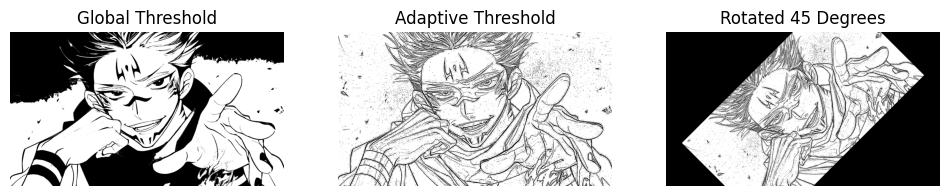

In [ ]:
# TASK 07 ---> Matrix-based rotation and adaptive thresholding

# global binary thresholding
ret, binary = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)

adaptive= cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

height, width = image_gray.shape[:2]
center = (width //2, height //2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)

rotated = cv2.warpAffine(adaptive, rotation_matrix, (width, height))
    # Display results side by side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rotated, cmap="gray")
plt.title("Rotated 45 Degrees")
plt.axis("off")

plt.show()

In [28]:
image1
image2

array([[[ 61,  20, 255],
        [ 50,  11, 243],
        [ 40,  10, 235],
        ...,
        [229, 211, 204],
        [228, 210, 203],
        [228, 210, 203]],

       [[ 61,  22, 251],
        [ 57,  23, 248],
        [ 44,  15, 238],
        ...,
        [228, 210, 203],
        [229, 211, 204],
        [229, 211, 204]],

       [[ 53,  19, 237],
        [ 57,  26, 243],
        [ 53,  26, 244],
        ...,
        [229, 211, 204],
        [230, 212, 205],
        [230, 212, 205]],

       ...,

       [[102,  79,  77],
        [102,  79,  77],
        [101,  78,  76],
        ...,
        [ 12,   3,  76],
        [ 11,   3,  74],
        [ 11,   3,  73]],

       [[100,  77,  75],
        [101,  78,  76],
        [103,  80,  78],
        ...,
        [ 15,   7,  78],
        [ 13,   5,  75],
        [ 12,   5,  72]],

       [[103,  80,  78],
        [106,  83,  81],
        [106,  83,  81],
        ...,
        [ 19,  11,  82],
        [ 16,   8,  78],
        [ 13,   6,  73]]

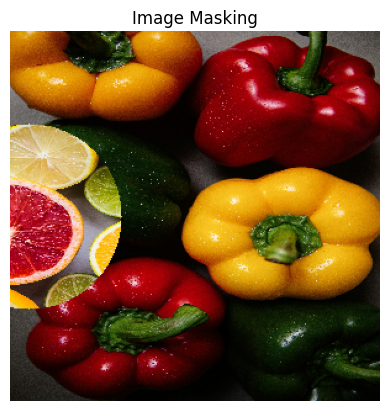

In [ ]:
# TASK 08 ---> Image masking and bitwise operations

image1 = cv2.resize(image1, (300,300))
image2 = cv2.resize(image2, (300,300))

mask = np.ones((300,300), dtype = np.uint8) * 255

cv2.circle(mask, (15,150), 75, 0, -1)

outside = cv2.bitwise_and(image1, image1, mask = mask)
inverted_mask = cv2.bitwise_not(mask)

inside = cv2.bitwise_and(image2, image2, mask = inverted_mask)

result = cv2.bitwise_or(outside, inside)

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(result_rgb)
plt.title("Image Masking")
plt.axis("off")
plt.show()

In [ ]:
# TAsK 09 ----> Statistical Image profiling with pandas
import cv2
import pandas as pd

# Load the image
image = cv2.imread("sukuna.jpg")

if image is None:
    print("Error: Image not found.")

else:
    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(
        image, cv2.COLOR_BGR2RGB
    )

    # Separate the color channels
    red = image_rgb[:, :, 0].flatten()
    green = image_rgb[:, :, 1].flatten()
    blue = image_rgb[:, :, 2].flatten()

    # Create a DataFrame
    data = pd.DataFrame({
        "Red": red,
        "Green": green,
        "Blue": blue
    })

    # Display the first five rows
    print("First five pixels:")
    print(data.head())

    # Display statistical summary
    print("\nImage Color Statistics:")
    print(data.describe())

First five pixels:
   Red  Green  Blue
0   78     30    42
1   78     30    42
2   78     30    42
3   78     30    42
4   78     30    42

Image Color Statistics:
                Red         Green          Blue
count  2.073600e+06  2.073600e+06  2.073600e+06
mean   1.981238e+02  1.185954e+02  1.022350e+02
std    7.551837e+01  6.341618e+01  5.816727e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.590000e+02  6.300000e+01  5.000000e+01
50%    2.400000e+02  1.170000e+02  9.900000e+01
75%    2.530000e+02  1.720000e+02  1.520000e+02
max    2.550000e+02  2.550000e+02  2.550000e+02


# Lab 02 PHOTOMETRIC / POINT TRANSFORMATIONS

### BASIC IDEA

Point transformation mein **har pixel independently** transform hota hai; neighboring pixels ki zaroorat nahi hoti.

$$
\boxed{s=T(r)}
$$

\(r\)=input intensity, \(s\)=output intensity
8-bit grayscale: \(0\le r,s\le255\)

---

### 1️⃣ NEGATIVE TRANSFORMATION

**Idea:** Image ki intensity reverse kar deta hai → dark becomes bright & bright becomes dark.

$$
\boxed{s=L-1-r}
$$

8-bit:

$$
\boxed{s=255-r}
$$

**Use:** X-rays, photographic negatives, dark details ko emphasize karna.

---

### 2️⃣ LOG TRANSFORMATION

**Idea:** Low/dark intensity values ko expand karta hai aur high intensity values ko compress karta hai.

$$
\boxed{s=c\log(1+r)}
$$

**Use:** Dark regions ki hidden details enhance karna; large dynamic range compress karna.

⭐ **Remember:**

$$
\boxed{\text{LOG → Dark details}}
$$

---

### 3️⃣ GAMMA / POWER-LAW TRANSFORMATION

$$
\boxed{s=cr^\gamma}
$$

**Main purpose:** Brightness / intensity correction.

$$
\gamma<1\rightarrow\boxed{\text{Brighter}}
$$

$$
\gamma=1\rightarrow\boxed{\text{Same (if }c=1\text{)}}
$$

$$
\gamma>1\rightarrow\boxed{\text{Darker}}
$$

 **Remember:**
**Gamma ↓ → Bright**
**Gamma ↑ → Dark**

---

### 4️⃣ LINEAR TRANSFORMATION

$$
\boxed{s=ar+b}
$$

\(a\) → contrast control
\(b\) → brightness shift

* \(a>1\) → contrast increases
* \(0<a<1\) → contrast decreases
* \(b>0\) → brighter
* \(b<0\) → darker

---

### 5️⃣ PIECEWISE TRANSFORMATION

**Idea:** Different intensity ranges ke liye **different formulas** use karte hain.

$$
\boxed{
s=
\begin{cases}
T_1(r)&\text{range 1}\\
T_2(r)&\text{range 2}\\
T_3(r)&\text{range 3}
\end{cases}}
$$

 **Key point:**
**Piecewise = intensity ko pieces/ranges mein divide karna.**

---

### 6️⃣ CONTRAST STRETCHING

**Idea:** Low-contrast image ki limited intensity range ko **expand** karta hai.

$$
\boxed{
s=s_{min}+
\frac{(r-r_{min})(s_{max}-s_{min})}
{r_{max}-r_{min}}
}
$$

Common 8-bit case:

$$
\boxed{s=\frac{255(r-r_1)}{r_2-r_1}}
$$

**Use:** Low-contrast images ko improve karna.

⭐ **Remember:**

$$
\boxed{\text{Stretching → Expand intensity range}}
$$

---

### 7️⃣ THRESHOLDING

**Idea:** Pixels ko threshold ke basis par usually **2 classes** mein divide karta hai: foreground & background.

$$
\boxed{
s=
\begin{cases}
0,&r<T\\
L-1,&r\ge T
\end{cases}}
$$

8-bit → output usually **0 or 255**

**Use:** Object/background separation, segmentation.

⭐ **Threshold = Black/White decision**

---

### 8️⃣ INTENSITY-LEVEL SLICING

**Idea:** Ek specific intensity range ko **highlight** karna.

For range \(A\) to \(B\):

$$
\boxed{
s=
\begin{cases}
L-1,&A\le r\le B\\
0,&\text{otherwise}
\end{cases}}
$$

**Use:** Specific objects/features highlight karna, e.g. medical images.

⭐ **Slicing = Highlight a range**

---

### 9️⃣ HISTOGRAM

**Definition:** Histogram batata hai ke image mein **har intensity value ke kitne pixels** hain.

$$
\boxed{h(r_k)=n_k}
$$

* X-axis → intensity values
* Y-axis → number/frequency of pixels

Total pixels:

$$
\boxed{N=\sum n_k}
$$

**Histogram left side concentrated → Dark image**

**Histogram right side concentrated → Bright image**

**Narrow range → Usually low contrast**

**Wide range → Usually better contrast**

---

### 🔟 NORMALIZED HISTOGRAM

Histogram ko probability mein convert karte hain:

$$
\boxed{p(r_k)=\frac{n_k}{N}}
$$

where:

$$
\boxed{\sum p(r_k)=1}
$$

---

### 1️⃣1️⃣ CDF

**CDF = Cumulative Distribution Function**

Yani current intensity tak **saari probabilities add** karna:

$$
\boxed{
CDF(r_k)=\sum_{j=0}^{k}p(r_j)
}
$$

---

### 1️⃣2️⃣ HISTOGRAM EQUALIZATION ⭐⭐⭐

**Idea:** Histogram/CDF ke through intensity values ko redistribute karke **image contrast improve** karna.

$$
\boxed{s_k=(L-1)CDF(r_k)}
$$

Usually:

$$
\boxed{s_k=\operatorname{round}[(L-1)CDF(r_k)]}
$$

### Numerical steps:

$$
\boxed{
n_k
\rightarrow
p(r_k)=\frac{n_k}{N}
\rightarrow
CDF
\rightarrow
s_k=(L-1)CDF
}
$$

⭐ **Remember:**
**Equalization → CDF → Contrast improvement**

---

#  MOST IMPORTANT CONCEPTUAL DIFFERENCES

**Point Transformation:**
→ Each pixel independently.

**Log:**
→ Dark details enhance.

**Gamma:**
→ Brightness correction.

**Piecewise:**
→ Different ranges, different transformations.

**Contrast Stretching:**
→ Intensity range expand.

**Thresholding:**
→ Pixels divided into classes (usually black/white).

**Intensity Slicing:**
→ Specific intensity range highlight.

**Histogram:**
→ Pixel-intensity distribution/count.

**Histogram Equalization:**
→ CDF-based intensity redistribution → contrast improvement.

---

#  EXAM QUESTION → ANSWER

**"Dark image ki details enhance karo"** → LOG

**"Brightness correct karo using γ"** → GAMMA

**"Low contrast image improve karo"** → CONTRAST STRETCHING / HISTOGRAM EQUALIZATION

**"Specific intensity range highlight karo"** → INTENSITY SLICING

**"Object/background separate karo"** → THRESHOLDING

**"Har intensity ke pixels count karne hain"** → HISTOGRAM

**"CDF use karke contrast improve karna hai"** → HISTOGRAM EQUALIZATION

**"Different intensity ranges ke different formulas"** → PIECEWISE

---

#  10-SECOND REVISION

$$
\boxed{
\begin{array}{ll}
Negative &\rightarrow Reverse\\
Log &\rightarrow Dark\ Details\\
Gamma &\rightarrow Brightness\\
Piecewise &\rightarrow Different\ Ranges\\
Stretching &\rightarrow Expand\ Range\\
Threshold &\rightarrow Black/White\\
Slicing &\rightarrow Highlight\ Range\\
Histogram &\rightarrow Count\ Pixels\\
CDF &\rightarrow Cumulative\ Probability\\
Equalization &\rightarrow Improve\ Contrast
\end{array}}
$$


In [ ]:
#task-01 ----> diagnostic enhancement of chest X-rays

import cv2
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. LOAD IMAGE
# --------------------------------------------------

image = cv2.imread("data/sample_xray.png", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image could not be loaded.")
    exit()

print("Image shape:", image.shape)


# --------------------------------------------------
# 2. DISPLAY ORIGINAL IMAGE
# --------------------------------------------------

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Original X-Ray")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 3. HISTOGRAM EQUALIZATION
# --------------------------------------------------

equalized = cv2.equalizeHist(image)

plt.figure(figsize=(6, 6))
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized X-Ray")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 4. COLOR MAPPING
# --------------------------------------------------

heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap_rgb)
plt.title("JET Heatmap")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 5. COLOR BALANCE
# --------------------------------------------------

blue, green, red = cv2.split(heatmap)

blue = cv2.add(blue, 10)
green = cv2.add(green, 10)
red = cv2.add(red, 10)

balanced = cv2.merge([blue, green, red])

balanced_rgb = cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(balanced_rgb)
plt.title("Color Balanced Image")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 6. COLOR FILTERING - THRESHOLDING
# --------------------------------------------------

threshold_value = 200

_, thresholded = cv2.threshold(
    equalized,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6, 6))
plt.imshow(thresholded, cmap="gray")
plt.title("Thresholded Dense Tissue")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 7. LOGARITHMIC TRANSFORMATION
# --------------------------------------------------

image_float = image.astype(np.float32)

c = 255 / np.log(1 + np.max(image_float))

log_image = c * np.log(1 + image_float)

log_image = np.uint8(log_image)

plt.figure(figsize=(6, 6))
plt.imshow(log_image, cmap="gray")
plt.title("Logarithmic Transformation")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 8. POWER-LAW / GAMMA TRANSFORMATION
# --------------------------------------------------

gamma = 0.5

normalized = image / 255.0

gamma_image = np.power(normalized, gamma)

gamma_image = np.uint8(gamma_image * 255)

plt.figure(figsize=(6, 6))
plt.imshow(gamma_image, cmap="gray")
plt.title("Gamma Transformation")
plt.axis("off")
plt.show()

Image could not be loaded.


AttributeError: 'NoneType' object has no attribute 'shape'

: 

In [ ]:
# task 02 -----> Multimodal cardiac image fusion

import cv2
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. LOAD CT AND MRI
# --------------------------------------------------

ct = cv2.imread("data/ct_slice.png", cv2.IMREAD_GRAYSCALE)
mri = cv2.imread("data/mri_slice.png", cv2.IMREAD_GRAYSCALE)

if ct is None:
    print("CT image could not be loaded.")
    exit()

if mri is None:
    print("MRI image could not be loaded.")
    exit()


# --------------------------------------------------
# 2. CHECK IMAGE SIZES
# --------------------------------------------------

print("CT shape:", ct.shape)
print("MRI shape:", mri.shape)


# --------------------------------------------------
# 3. HISTOGRAM EQUALIZATION
# --------------------------------------------------

ct_equalized = cv2.equalizeHist(ct)
mri_equalized = cv2.equalizeHist(mri)


# --------------------------------------------------
# 4. COLOR MAPPING
# --------------------------------------------------
#JET:
# low intensity
#     ↓
# blue
#     ↓
# cyan
#     ↓
# green
#     ↓
# yellow
#     ↓
# red
#     ↓
# high intensity

# HOT ka visual effect aisa hota hai jaise:

# low intensity = cold/dark
# high intensity = hot/bright

# Isliye areas with higher values visually "hotter" nazar aate hain.

ct_color = cv2.applyColorMap(
    ct_equalized,
    cv2.COLORMAP_JET
)

mri_color = cv2.applyColorMap(
    mri_equalized,
    cv2.COLORMAP_HOT
)


# --------------------------------------------------
# 5. WEIGHTED FUSION
# --------------------------------------------------

alpha = 0.7
beta = 0.3
gamma = 0

fused = cv2.addWeighted(
    ct_equalized,
    alpha,
    mri_equalized,
    beta,
    gamma
)


# --------------------------------------------------
# 6. LOGARITHMIC TRANSFORMATION
# --------------------------------------------------

fused_float = fused.astype(np.float32)

c = 255 / np.log(1 + np.max(fused_float))

fused_log = c * np.log(1 + fused_float)

fused_log = np.uint8(fused_log)


# --------------------------------------------------
# 7. POWER-LAW / GAMMA TRANSFORMATION
# --------------------------------------------------

gamma_value = 0.8

normalized = fused_log / 255.0

fused_gamma = np.power(
    normalized,
    gamma_value
)

fused_gamma = np.uint8(fused_gamma * 255)


# --------------------------------------------------
# 8. DISPLAY RESULTS
# --------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ct_equalized, cmap="gray")
plt.title("CT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mri_equalized, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(fused_gamma, cmap="gray")
plt.title("Fused CT + MRI")
plt.axis("off")

plt.show()

In [ ]:
# task 03 -------> real-time echocardiogram video analysis and enhancement

import cv2
import numpy as np


# --------------------------------------------------
# 1. OPEN VIDEO
# --------------------------------------------------

video = cv2.VideoCapture("data/echo_sample.mp4")

if not video.isOpened():
    print("Video could not be opened.")
    exit()


# --------------------------------------------------
# 2. PROCESS VIDEO FRAME BY FRAME
# --------------------------------------------------

while True:

    ret, frame = video.read()

    if not ret:
        break


    # ----------------------------------------------
    # 3. CONVERT FRAME TO GRAYSCALE
    # ----------------------------------------------

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )


    # ----------------------------------------------
    # 4. HISTOGRAM EQUALIZATION
    # ----------------------------------------------

    equalized = cv2.equalizeHist(gray)


    # ----------------------------------------------
    # 5. COLOR MAPPING
    # ----------------------------------------------

    heatmap = cv2.applyColorMap(
        equalized,
        cv2.COLORMAP_JET
    )


    # ----------------------------------------------
    # 6. COLOR BALANCE
    # ----------------------------------------------

    blue, green, red = cv2.split(heatmap)

    blue = cv2.add(blue, 10)
    green = cv2.add(green, 10)
    red = cv2.add(red, 10)

    balanced = cv2.merge(
        [blue, green, red]
    )


    # ----------------------------------------------
    # 7. LOG TRANSFORMATION
    # ----------------------------------------------

    balanced_gray = cv2.cvtColor(
        balanced,
        cv2.COLOR_BGR2GRAY
    )

    balanced_float = balanced_gray.astype(
        np.float32
    )

    c = 255 / np.log(
        1 + np.max(balanced_float)
    )

    log_image = c * np.log(
        1 + balanced_float
    )

    log_image = np.uint8(log_image)


    # ----------------------------------------------
    # 8. POWER-LAW / GAMMA TRANSFORMATION
    # ----------------------------------------------

    gamma = 0.7

    normalized = log_image / 255.0

    gamma_image = np.power(
        normalized,
        gamma
    )

    gamma_image = np.uint8(
        gamma_image * 255
    )


    # ----------------------------------------------
    # 9. CONVERT FINAL RESULT TO COLOR
    # ----------------------------------------------

    final_heatmap = cv2.applyColorMap(
        gamma_image,
        cv2.COLORMAP_JET
    )


    # ----------------------------------------------
    # 10. RESIZE IF NECESSARY
    # ----------------------------------------------

    height = min(
        frame.shape[0],
        final_heatmap.shape[0]
    )

    width = min(
        frame.shape[1],
        final_heatmap.shape[1]
    )

    frame_resized = cv2.resize(
        frame,
        (width, height)
    )

    enhanced_resized = cv2.resize(
        final_heatmap,
        (width, height)
    )


    # ----------------------------------------------
    # 11. SIDE-BY-SIDE DISPLAY
    # ----------------------------------------------

    combined = cv2.hconcat(
        [frame_resized, enhanced_resized]
    )


    cv2.imshow(
        "Original | Enhanced",
        combined
    )


    # ----------------------------------------------
    # 12. PRESS Q TO EXIT
    # ----------------------------------------------

    if cv2.waitKey(25) & 0xFF == ord("q"):
        break


# --------------------------------------------------
# 13. RELEASE VIDEO
# --------------------------------------------------

video.release()

cv2.destroyAllWindows()

# ***LAB 03***

In [ ]:
# practice tasks below

# loading and displaying the image using OpenCV and Matplotlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread("fruits.jpg")

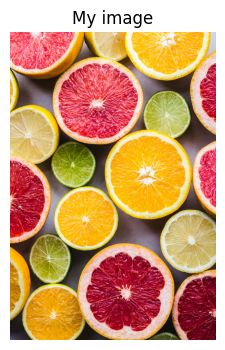

In [3]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12, 4))
plt.imshow(image)
plt.axis("off")
plt.title("My image")
plt.show()

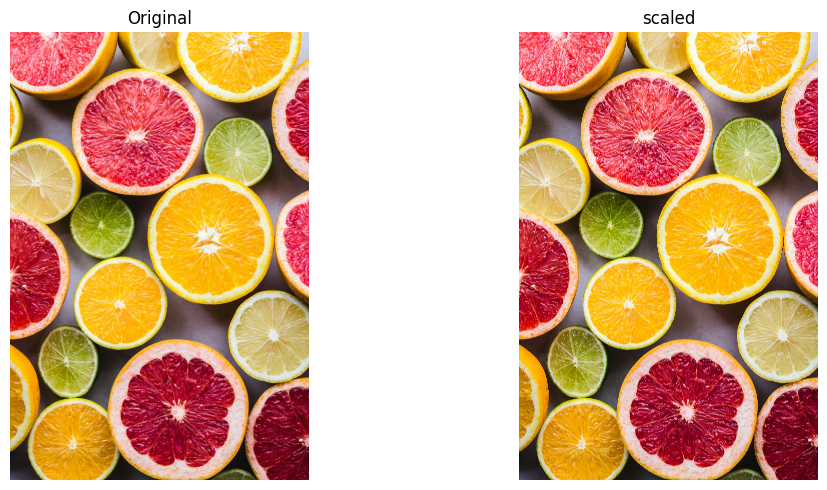

In [ ]:
# scaling/resizing
image = cv2.imread("data/sample_image.jpg")

if image is None:
    print("Image could not be loaded.")
    exit()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(scaled)
plt.title("scaled")
plt.axis("off")

plt.tight_layout()
plt.show()

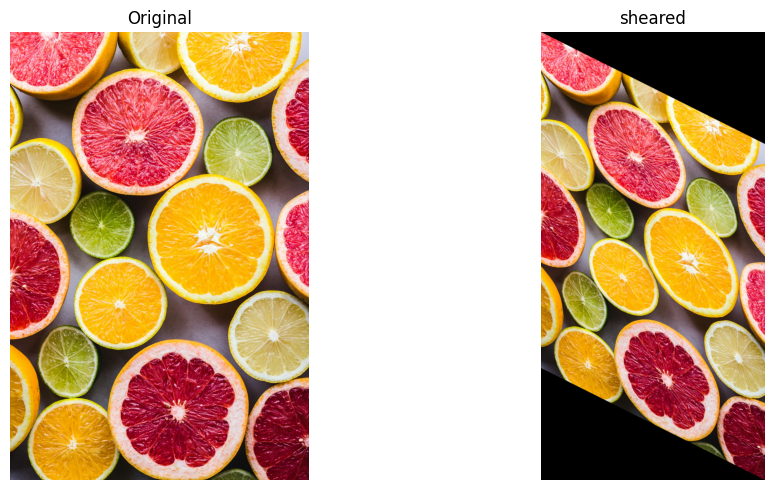

In [7]:
# shearing

height, width = image.shape[:2]

ky = 0.5

M = np.float32([[1, 0, 0],[ky,1,0]])

new_height = int(width*abs(ky)+height)

sheared = cv2.warpAffine(image, M, (width, new_height))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sheared)
plt.title("sheared")
plt.axis("off")

plt.tight_layout()
plt.show()

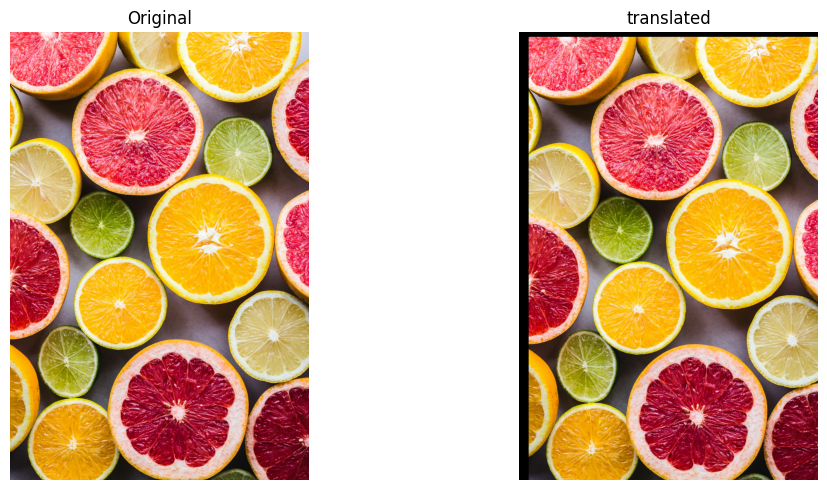

In [ ]:
#translation

tx = 100
ty = 50

M = np.float32([[1,0,tx],[0,1,ty]])

translated = cv2.warpAffine(image, M, (width, height))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(translated)
plt.title("translated")
plt.axis("off")

plt.tight_layout()
plt.show()                      

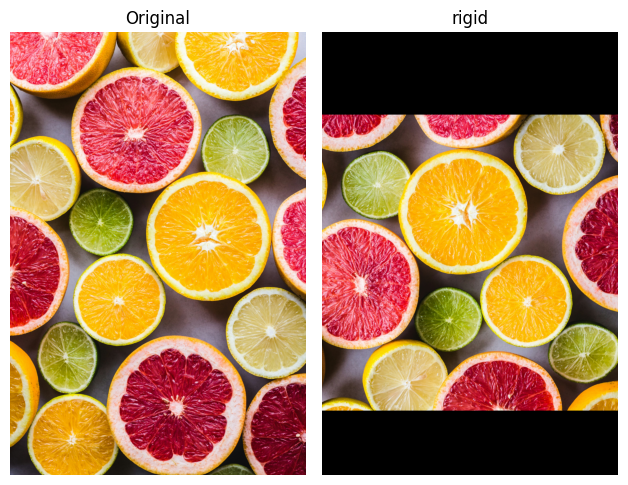

In [11]:
# rigid transformation: szie is preserved, only rotation + translation happens

center = (width //2, height // 2)

angle = 90

scale = 1.0

# rotation matrix
M = cv2.getRotationMatrix2D(center, angle, scale)

# Add translation
M[0,2] += 100
M[1,2] += 100

# Apply rigid transformation

rigid = cv2.warpAffine(image, M, (width, height))


plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rigid)
plt.title("rigid")
plt.axis("off")

plt.tight_layout()
plt.show()   

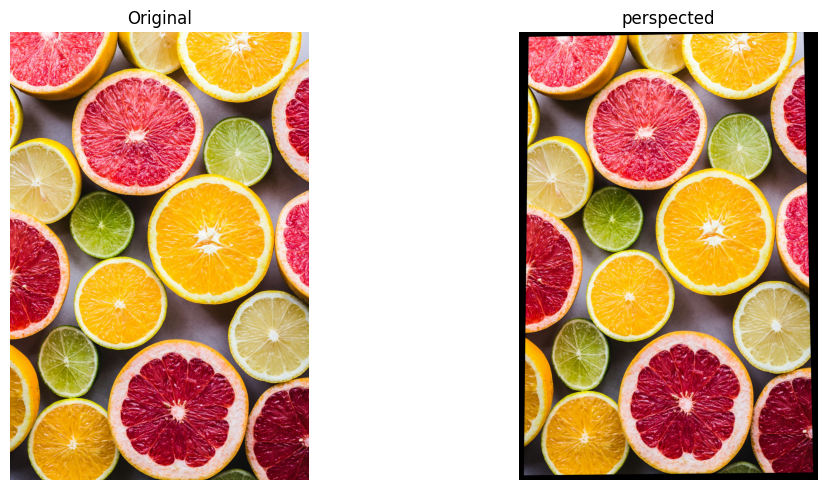

In [12]:
# projective -> perspective trasformation

src_pts= np.float32([[0,0],[width-1, 0],[width-1, height-1],[0, height -1]])

dest_pts = np.float32([[100, 50],[width-150, 0],[width-50, height-80],[50, height-50]])

# obtain homography matrix
M = cv2.getPerspectiveTransform(src_pts, dest_pts)

pers = cv2.warpPerspective(image, M, (width, height))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pers)
plt.title("perspected")
plt.axis("off")

plt.tight_layout()
plt.show()                      


# Lab tasks

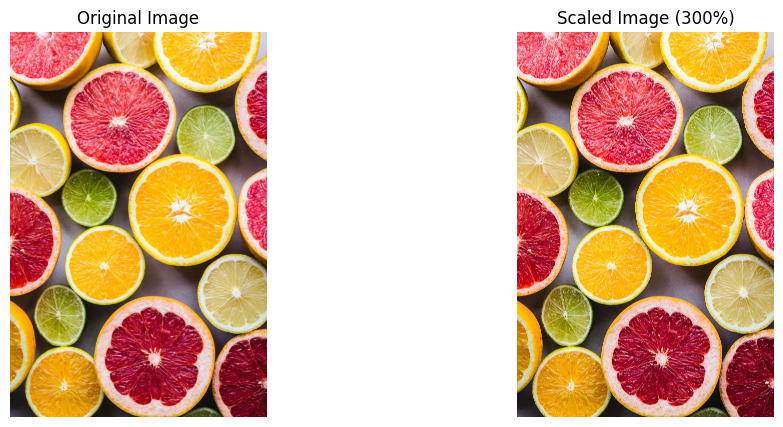

In [15]:
# lab task 01

#scaling factor
sx= 3
sy = 3
s = np.float32([[sx,0],[0,sy]])

new_width = width*sx
new_height = height*sy

scaled = cv2.resize(image, (new_width, new_height), interpolation = cv2.INTER_LINEAR)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(scaled)
plt.title("Scaled Image (300%)")
plt.axis("off")

plt.show()

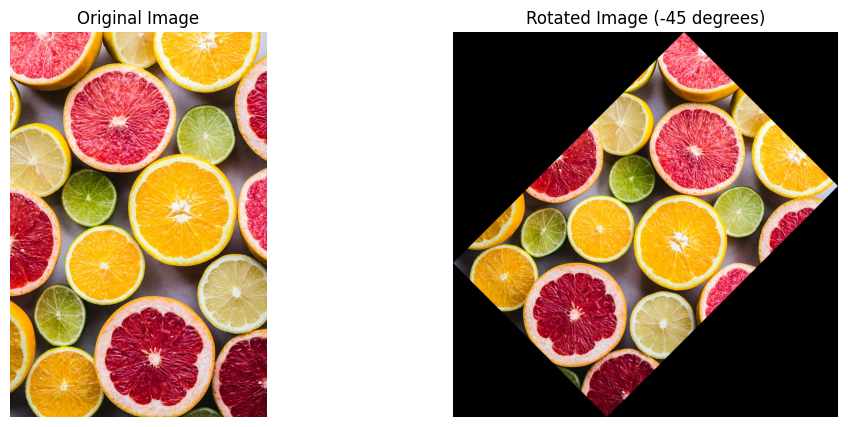

In [ ]:
# TASK # 02
angle = -45

theta = np.radians(angle)

R = np.float32([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])

center= (width // 2, height // 2)

 # Calculate new dimensions
new_width = int(
        abs(height * np.sin(theta)) +
        abs(width * np.cos(theta))
    )
new_height = int(
        abs(height * np.cos(theta)) +
        abs(width * np.sin(theta))
    )
M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Move rotated image to center of new canvas
M[0, 2] += (new_width / 2) - center[0]
M[1, 2] += (new_height / 2) - center[1]

rotated = cv2.warpAffine(image, M, (new_width, new_height))
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated)
plt.title("Rotated Image (-45 degrees)")
plt.axis("off")

plt.show()


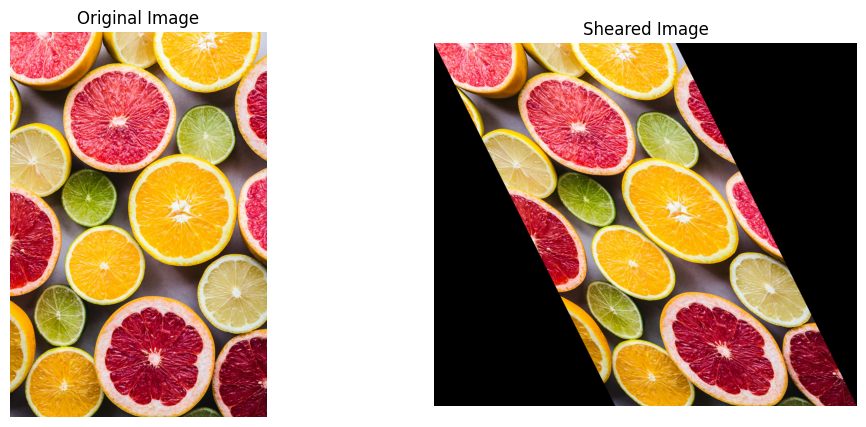

In [18]:
# task 3
# the fast train barcode (Linear - shear)
kx = 0.5

H = np.array([[1, kx],[0, 1]], dtype = np.float32)

new_width = int(width + height*abs(kx))

M = np.array([[1, kx, 0],[0, 1, 0]], dtype = np.float32)

sheared = cv2.warpAffine(image, M, (new_width, height))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sheared)
plt.title("Sheared Image")
plt.axis("off")

plt.show()

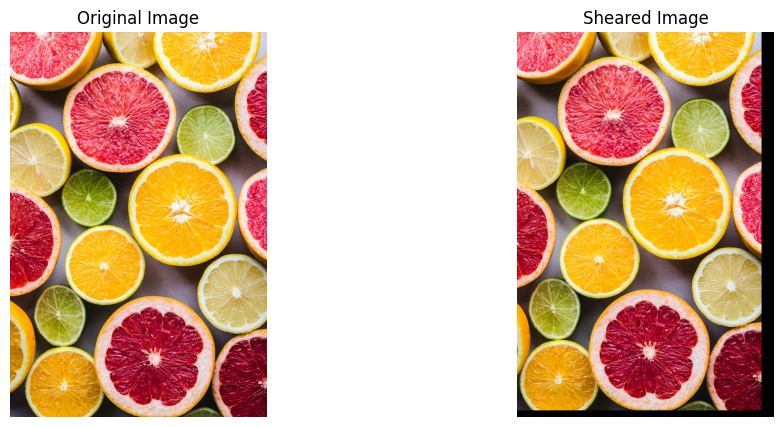

In [ ]:
# task 04 - The hidden treasure map
# Affine - translaation
tx = -150
ty = -80

T = np.array([[1,0,tx],[0,1,ty], [0,0,1]], dtype=np.float32)

T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float32)
M = T[:2, :]
translated = cv2.warpAffine(
        image,
        M,
        (width, height)
    )

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated)
plt.title("Sheared Image")
plt.axis("off")

plt.show()



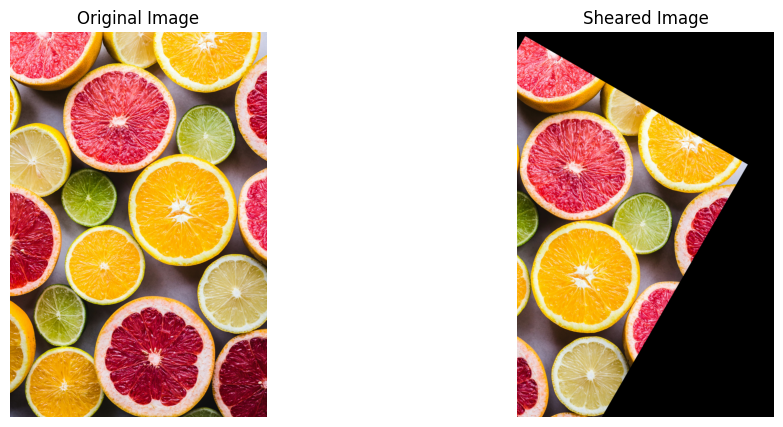

In [ ]:
# robot's asembly wla task # 05 (RIGID TRANSFORMATION)

angle = 30
theta = np.radians(angle)

center = (width //2, height // 2)

tx = 100
ty = 50

R = np.array([[np.cos(theta), -np.sin(theta), 0],[np.sin(theta), np.cos(theta), 0], [0,0,1]], dtype=np.float32)

T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype = np.float32)

M = T @ R

M = M[:2, :]


rigid = cv2.warpAffine(image, M, (width, height))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rigid)
plt.title("Sheared Image")
plt.axis("off")

plt.show()



In [ ]:
# Translate + Rotate + Scale(Rigid transformation)
# Similarity translation: preserves the shape(angles and sides) of the object, but allows for scaling, rotation, and translation.
angle = 30
theta = np.radians(angle)
scale = 0.5
tx=100
ty = 50

R = np.array([[np.cos(theta), -np.sin(theta), 0],[np.sin(theta), np.cos(theta), 0],[0,0,1]], dtype = np.float32)
T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float32)
S = np.array([[scale, 0, 0],[0, scale, 0],[0,0,1]], dtype=np.float32)

M = T@R@S

M = M[:2,:]

rigid = cv2.warpAffine(image, M, (width, height))


In [ ]:
# task 07 - general affine transformation
# we are assuming/making up the three src and dest points

src_pts = np.float32([[100,100],[300,100],[100,300]])

dest_pts = np.float32([[120,130],[350,100],[100,330]])
M = cv2.getAffineTransform(src_pts, dest_pts)

transformed = cv2.warpAffine(image, M, (width, height))



In [ ]:
# task-08 projective-perspective transformation

src_pts = np.float([[100,80],[500,120],[550,400],[80,400]])

dest_pts = np.float([[0,0],[500,0],[500,300],[0,300]])

H = cv2.getPerspectiveTransform(src_pts, dest_pts)

transformed = cv2.warpPerspective(image, H, (500, 300))



In [ ]:
# task 09 --- panorama shit (Projective homography transformation)
points1 = np.float32([
        [100, 100],
        [500, 100],
        [500, 400],
        [100, 400]
    ])

    # Same four physical points in image 2
points2 = np.float32([
        [80, 120],
        [450, 80],
        [480, 380],
        [120, 420]
    ])

H, status = cv2.findHomography(points2, points1, cv2.RANSAC)
height1, width1 = image1.shape[:2]

height2, width2 = image2.shape[:2]

warped_image2 = cv2.warpPerspective(image2, H, (width1+width2, max(height1, height2)))

warped_image2[0:height1, 0:width1]= image1



In [ ]:
# task 10 - mega tasssssskkkkkkkkk(Full heirerchy challenge) ek image ko painting ke andr fit krwana tha hanging on a wall

# we assume that we have successfully read the painting into image
scale = 0.5

scaled = cv2.resize(image, None, fx = scale, fy = scale, interpolation = cv2.INTER_LINEAR)

# rigid transformation: rotation + translation
height , width = scaled.shape[:2]

center = (width // 2, height //2)

angle = 10

tx = 100
ty = 80

M = cv2.getRotationMatrix2D(center, angle, 1.0)

M[0,2] += tx
M[1,2] += ty

rigid = cv2.warpAffine(scaled, M, (width+200, height+200))
h, w = rigid.shape[:2]

src_pts = np.float32([[0,0],[w-1,0],[w-1, h-1],[0, h-1]])
dest_pts = np.float32([[150, 100],
        [500, 60],
        [550, 400],
        [100, 450]])

H = cv2.getPerspectiveTransform(src_pts, dest_pts)

final = cv2.warpPerpective(rigid, H, (w+200, h+200))


